# Market Dimensionality / Opportunity Set — Feasibility Test v0.5

## Objetivo desta versão

A v0.2 mostrou que, no universo bruto de 9 ETFs setoriais dos EUA, **Effective Rank (participation ratio), mean correlation e market mode ordenam os estados de mercado quase da mesma forma**.

A v0.3 faz duas coisas antes de tocar em alpha:

1. **audita matematicamente o Effective Rank**, deixando explícita sua redundância com correlações ao quadrado quando \(N\) é fixo;
2. testa se a estrutura continua essencialmente a mesma **depois de remover o fator de mercado (SPY)**.

> **Ainda não há backtest de estratégia nesta versão.**
> O objetivo é decidir se existe uma variável estrutural suficientemente defensável para justificar o próximo passo.

## Research question desta etapa

> Depois de retirar o movimento comum do mercado, sobra uma estrutura cross-sectional suficientemente distinta e estável para justificar a tese de *Opportunity Set*?

## Hipóteses

- **H1 — sanity estrutural:** o ER bruto mede concentração de co-movimento.
- **H2 — auditoria matemática:** o participation-ratio ER é uma transformação monotônica da correlação quadrática agregada para \(N\) fixo.
- **H3 — residualização:** retirar SPY deve reduzir o domínio do fator comum e pode revelar uma estrutura relativa diferente.
- **H4 — decisão:** só avançaremos para alpha se a estrutura residual acrescentar uma pergunta econômica útil.

## 0. Regras metodológicas congeladas

- Universo: `XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY`.
- Fator de mercado: `SPY`.
- Frequência: retornos diários; observação estrutural mensal.
- Janela-base: **252 pregões**.
- Nenhum dado posterior a \(t\) entra na estimativa em \(t\).
- OLS de mercado estimado dentro da própria janela histórica disponível em \(t\).
- Nenhum threshold de trading nesta versão.
- Nenhuma métrica será promovida porque “parece melhor” visualmente.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError("Instale yfinance antes de rodar: pip install yfinance") from exc

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_TICKERS = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
MARKET_TICKER = "SPY"
ALL_TICKERS = SECTOR_TICKERS + [MARKET_TICKER]

START = "2000-01-01"
END = None
WINDOW = 252
MIN_COVERAGE = 0.98

CACHE_FILE = DATA_DIR / "us_sector_etfs_plus_spy_adjusted_close.csv"

## 1. Dados

A v0.3 usa um novo cache porque agora precisamos também do SPY.

In [2]:
def load_prices(force_download: bool = False) -> pd.DataFrame:
    if CACHE_FILE.exists() and not force_download:
        return pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True).sort_index()

    raw = yf.download(
        ALL_TICKERS,
        start=START,
        end=END,
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )

    if raw.empty:
        raise RuntimeError("Download retornou vazio.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        elif "Close" in raw.columns.get_level_values(1):
            prices = raw.xs("Close", axis=1, level=1).copy()
        else:
            raise KeyError("Coluna Close não encontrada.")
    else:
        prices = raw[["Close"]].rename(columns={"Close": ALL_TICKERS[0]})

    prices = prices.reindex(columns=ALL_TICKERS).sort_index()
    prices.to_csv(CACHE_FILE)
    return prices

prices = load_prices()

coverage = prices.notna().mean().sort_values()
display(coverage.to_frame("coverage"))

first_valid_dates = prices.apply(pd.Series.first_valid_index)
common_start = max(first_valid_dates)

px = prices.loc[common_start:].copy()
daily_coverage = px.notna().mean(axis=1)
px = px.loc[daily_coverage >= MIN_COVERAGE]
px = px.ffill(limit=3).dropna(how="any")

print("Common start:", common_start)
print("Observações:", len(px))
print("Início:", px.index.min())
print("Fim:", px.index.max())

assert set(ALL_TICKERS).issubset(px.columns)
assert not px.isna().any().any()

,coverage
XLB,1.0
XLE,1.0
XLF,1.0
XLI,1.0
XLK,1.0
XLP,1.0
XLU,1.0
XLV,1.0
XLY,1.0
SPY,1.0


Common start: 2000-01-03 00:00:00
Observações: 6690
Início: 2000-01-03 00:00:00
Fim: 2026-08-10 00:00:00


In [3]:
log_returns = np.log(px / px.shift(1)).dropna()

sector_returns = log_returns[SECTOR_TICKERS].copy()
market_returns = log_returns[MARKET_TICKER].copy()

display(sector_returns.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
XLB,0.000299,0.014864,-0.132527,0.131533
XLE,0.000330,0.018204,-0.224910,0.152504
XLF,0.000247,0.017813,-0.182322,0.152394
XLI,0.000348,0.013367,-0.120408,0.119126
XLK,0.000329,0.016307,-0.148662,0.149296
XLP,0.000292,0.009433,-0.098668,0.081678
XLU,0.000308,0.012106,-0.120561,0.120388
XLV,0.000316,0.011207,-0.103818,0.113817
XLY,0.000355,0.014315,-0.135461,0.103351


# 2. Auditoria matemática do participation-ratio Effective Rank

Para uma matriz de correlação \(C\) com \(N\) ativos:

\[
ER =
\frac{(\sum_i \lambda_i)^2}
{\sum_i \lambda_i^2}
\]

Como \(\sum_i \lambda_i=N\) e

\[
\sum_i \lambda_i^2
=
\operatorname{tr}(C^2)
=
N + 2\sum_{i<j}\rho_{ij}^2,
\]

temos:

\[
ER =
\frac{N^2}
{N + 2\sum_{i<j}\rho_{ij}^2}.
\]

Se

\[
\overline{\rho^2}
=
\frac{2}{N(N-1)}
\sum_{i<j}\rho_{ij}^2,
\]

então:

\[
\boxed{
ER =
\frac{N}
{1+(N-1)\overline{\rho^2}}
}
\]

Portanto, para \(N\) fixo, esse ER é uma transformação monotônica da correlação quadrática agregada.

In [4]:
def structural_metrics_from_corr(corr: np.ndarray) -> dict[str, float]:
    n = corr.shape[0]

    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.clip(eigvals, 0.0, None)
    eigvals = np.sort(eigvals)[::-1]

    total = eigvals.sum()
    er = (total ** 2) / np.square(eigvals).sum()
    market_mode = eigvals[0] / total

    upper = corr[np.triu_indices(n, k=1)]
    mean_corr = np.mean(upper)
    mean_abs_corr = np.mean(np.abs(upper))
    mean_sq_corr = np.mean(np.square(upper))
    rms_corr = np.sqrt(mean_sq_corr)

    er_from_mean_sq = n / (1.0 + (n - 1.0) * mean_sq_corr)

    return {
        "effective_rank": float(er),
        "market_mode": float(market_mode),
        "mean_corr": float(mean_corr),
        "mean_abs_corr": float(mean_abs_corr),
        "mean_sq_corr": float(mean_sq_corr),
        "rms_corr": float(rms_corr),
        "er_from_mean_sq": float(er_from_mean_sq),
    }

## 3. Estrutura bruta

O erro numérico entre `effective_rank` e `er_from_mean_sq` deve ser praticamente zero.

In [5]:
def rolling_raw_structure(sector_rets: pd.DataFrame, window: int = 252) -> pd.DataFrame:
    rows = []

    for end in range(window, len(sector_rets) + 1):
        w = sector_rets.iloc[end-window:end]
        corr = w.corr().to_numpy()

        metrics = structural_metrics_from_corr(corr)
        metrics["date"] = sector_rets.index[end - 1]
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("date")

raw_structure_daily = rolling_raw_structure(sector_returns, WINDOW)

identity_error = (
    raw_structure_daily["effective_rank"]
    - raw_structure_daily["er_from_mean_sq"]
).abs()

print("Máximo erro absoluto da identidade ER:", identity_error.max())
display(raw_structure_daily.tail())

Máximo erro absoluto da identidade ER: 4.440892098500626e-15


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-08-04,4.806795,0.364539,0.220243,0.278151,0.109044,0.330218,4.806795
2026-08-05,4.837398,0.362024,0.217297,0.276186,0.107563,0.327968,4.837398
2026-08-06,4.829381,0.362537,0.217250,0.276683,0.107949,0.328556,4.829381
2026-08-07,4.801365,0.364241,0.218682,0.278202,0.109308,0.330618,4.801365
2026-08-10,4.803874,0.364185,0.218878,0.277432,0.109186,0.330433,4.803874


# 4. Residualização point-in-time contra SPY

Para cada janela histórica terminando em \(t\), estimamos para cada setor:

\[
r_{i,\tau}
=
\alpha_{i,t}
+
\beta_{i,t}r_{SPY,\tau}
+
\epsilon_{i,\tau},
\qquad \tau \in [t-251,t].
\]

Depois usamos apenas os resíduos dessa janela histórica para construir a matriz de correlação residual.

Esta etapa **não assume** que residualização vai “salvar” o ER. Ela testa se o fator de mercado explica a redundância extrema observada nos retornos brutos.

In [6]:
def residualize_window_against_market(
    sector_window: pd.DataFrame,
    market_window: pd.Series,
) -> pd.DataFrame:
    # OLS univariado com intercepto, estimado separadamente por ativo.
    m = market_window.to_numpy(dtype=float)
    m_mean = m.mean()
    m_centered = m - m_mean
    var_m = np.dot(m_centered, m_centered)

    if var_m <= 0:
        raise ValueError("Variância do fator de mercado é zero.")

    residuals = pd.DataFrame(
        index=sector_window.index,
        columns=sector_window.columns,
        dtype=float,
    )

    for ticker in sector_window.columns:
        y = sector_window[ticker].to_numpy(dtype=float)
        y_mean = y.mean()
        y_centered = y - y_mean

        beta = np.dot(m_centered, y_centered) / var_m
        alpha = y_mean - beta * m_mean

        fitted = alpha + beta * m
        residuals[ticker] = y - fitted

    return residuals


def rolling_residual_structure(
    sector_rets: pd.DataFrame,
    market_rets: pd.Series,
    window: int = 252,
) -> pd.DataFrame:
    aligned = sector_rets.join(market_rets.rename("market"), how="inner").dropna()
    sectors = aligned[sector_rets.columns]
    market = aligned["market"]

    rows = []

    for end in range(window, len(aligned) + 1):
        sector_w = sectors.iloc[end-window:end]
        market_w = market.iloc[end-window:end]

        residuals = residualize_window_against_market(sector_w, market_w)
        corr_resid = residuals.corr().to_numpy()

        metrics = structural_metrics_from_corr(corr_resid)
        metrics["date"] = aligned.index[end - 1]
        rows.append(metrics)

    return pd.DataFrame(rows).set_index("date")


resid_structure_daily = rolling_residual_structure(
    sector_returns,
    market_returns,
    WINDOW,
)

display(resid_structure_daily.tail())

,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-08-04,5.288737,0.349099,0.058258,0.243426,0.087716,0.296169,5.288737
2026-08-05,5.292267,0.348797,0.057830,0.243137,0.087574,0.295930,5.292267
2026-08-06,5.283140,0.349314,0.058144,0.243484,0.087942,0.296549,5.283140
2026-08-07,5.264967,0.351003,0.058884,0.244514,0.088677,0.297786,5.264967
2026-08-10,5.265020,0.351297,0.058942,0.244902,0.088674,0.297782,5.265020


## 5. Amostragem mensal preservando a data real

In [7]:
def last_real_observation_each_month(df: pd.DataFrame) -> pd.DataFrame:
    month_key = df.index.to_period("M")
    return df.groupby(month_key, group_keys=False).tail(1).dropna()

raw_m = last_real_observation_each_month(raw_structure_daily)
resid_m = last_real_observation_each_month(resid_structure_daily)

print("RAW")
display(raw_m.tail())

print("RESIDUAL")
display(resid_m.tail())

RAW


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-04-30,4.112024,0.430303,0.316612,0.325641,0.148588,0.385471,4.112024
2026-05-29,4.424013,0.406094,0.278013,0.304224,0.129294,0.359575,4.424013
2026-06-30,4.671094,0.381052,0.245629,0.282264,0.115843,0.340357,4.671094
2026-07-31,4.804108,0.364479,0.222832,0.276391,0.109175,0.330416,4.804108
2026-08-10,4.803874,0.364185,0.218878,0.277432,0.109186,0.330433,4.803874


RESIDUAL


,effective_rank,market_mode,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,er_from_mean_sq
date,,,,,,,
2026-04-30,5.513484,0.341182,0.050304,0.229468,0.079045,0.281150,5.513484
2026-05-29,5.649467,0.333514,0.050199,0.227065,0.074134,0.272275,5.649467
2026-06-30,5.390133,0.347685,0.058447,0.241110,0.083715,0.289335,5.390133
2026-07-31,5.283897,0.349287,0.057918,0.243911,0.087911,0.296498,5.283897
2026-08-10,5.265020,0.351297,0.058942,0.244902,0.088674,0.297782,5.265020


# 6. Teste crítico: a residualização realmente muda a estrutura?

Comparamos Pearson e Spearman dentro das representações bruta e residual.

Se os descritores residuais continuarem quase perfeitamente redundantes, registramos isso; não inventamos uma narrativa.

In [8]:
cols = [
    "effective_rank",
    "mean_corr",
    "mean_abs_corr",
    "mean_sq_corr",
    "rms_corr",
    "market_mode",
]

print("RAW — Pearson")
display(raw_m[cols].corr(method="pearson"))

print("RAW — Spearman")
display(raw_m[cols].corr(method="spearman"))

print("RESIDUAL — Pearson")
display(resid_m[cols].corr(method="pearson"))

print("RESIDUAL — Spearman")
display(resid_m[cols].corr(method="spearman"))

RAW — Pearson


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.971046,-0.964287,-0.922781,-0.965225,-0.969422
mean_corr,-0.971046,1.000000,0.999263,0.984338,0.997251,0.998246
mean_abs_corr,-0.964287,0.999263,1.000000,0.988435,0.997936,0.998289
mean_sq_corr,-0.922781,0.984338,0.988435,1.000000,0.991283,0.988334
rms_corr,-0.965225,0.997251,0.997936,0.991283,1.000000,0.999506
market_mode,-0.969422,0.998246,0.998289,0.988334,0.999506,1.000000


RAW — Spearman


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.994578,-0.994654,-1.000000,-1.000000,-0.999478
mean_corr,-0.994578,1.000000,0.999979,0.994578,0.994578,0.996191
mean_abs_corr,-0.994654,0.999979,1.000000,0.994654,0.994654,0.996241
mean_sq_corr,-1.000000,0.994578,0.994654,1.000000,1.000000,0.999478
rms_corr,-1.000000,0.994578,0.994654,1.000000,1.000000,0.999478
market_mode,-0.999478,0.996191,0.996241,0.999478,0.999478,1.000000


RESIDUAL — Pearson


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.173586,-0.993140,-0.988489,-0.999277,-0.969999
mean_corr,-0.173586,1.000000,0.163552,0.224656,0.183729,0.349457
mean_abs_corr,-0.993140,0.163552,1.000000,0.979136,0.991753,0.959052
mean_sq_corr,-0.988489,0.224656,0.979136,1.000000,0.993251,0.970440
rms_corr,-0.999277,0.183729,0.991753,0.993251,1.000000,0.971445
market_mode,-0.969999,0.349457,0.959052,0.970440,0.971445,1.000000


RESIDUAL — Spearman


,effective_rank,mean_corr,mean_abs_corr,mean_sq_corr,rms_corr,market_mode
effective_rank,1.000000,-0.062797,-0.988016,-1.000000,-1.000000,-0.928742
mean_corr,-0.062797,1.000000,0.038800,0.062797,0.062797,0.265228
mean_abs_corr,-0.988016,0.038800,1.000000,0.988016,0.988016,0.903877
mean_sq_corr,-1.000000,0.062797,0.988016,1.000000,1.000000,0.928742
rms_corr,-1.000000,0.062797,0.988016,1.000000,1.000000,0.928742
market_mode,-0.928742,0.265228,0.903877,0.928742,0.928742,1.000000


In [9]:
comparison = pd.DataFrame({
    "raw_er": raw_m["effective_rank"],
    "resid_er": resid_m["effective_rank"],
    "raw_mean_corr": raw_m["mean_corr"],
    "resid_mean_corr": resid_m["mean_corr"],
    "raw_rms_corr": raw_m["rms_corr"],
    "resid_rms_corr": resid_m["rms_corr"],
    "raw_market_mode": raw_m["market_mode"],
    "resid_market_mode": resid_m["market_mode"],
}).dropna()

display(comparison.corr(method="pearson"))

,raw_er,resid_er,raw_mean_corr,resid_mean_corr,raw_rms_corr,resid_rms_corr,raw_market_mode,resid_market_mode
raw_er,1.000000,-0.259435,-0.971046,0.493710,-0.965225,0.255930,-0.969422,0.357022
resid_er,-0.259435,1.000000,0.253035,-0.173586,0.244389,-0.999277,0.261577,-0.969999
raw_mean_corr,-0.971046,0.253035,1.000000,-0.468446,0.997251,-0.249840,0.998246,-0.352913
resid_mean_corr,0.493710,-0.173586,-0.468446,1.000000,-0.503217,0.183729,-0.494778,0.349457
raw_rms_corr,-0.965225,0.244389,0.997251,-0.503217,1.000000,-0.242540,0.999506,-0.355413
resid_rms_corr,0.255930,-0.999277,-0.249840,0.183729,-0.242540,1.000000,-0.259508,0.971445
raw_market_mode,-0.969422,0.261577,0.998246,-0.494778,0.999506,-0.259508,1.000000,-0.368935
resid_market_mode,0.357022,-0.969999,-0.352913,0.349457,-0.355413,0.971445,-0.368935,1.000000


## 7. Visualização bruto vs residual

Padronização apenas para visualização; não será usada em nenhum sinal.

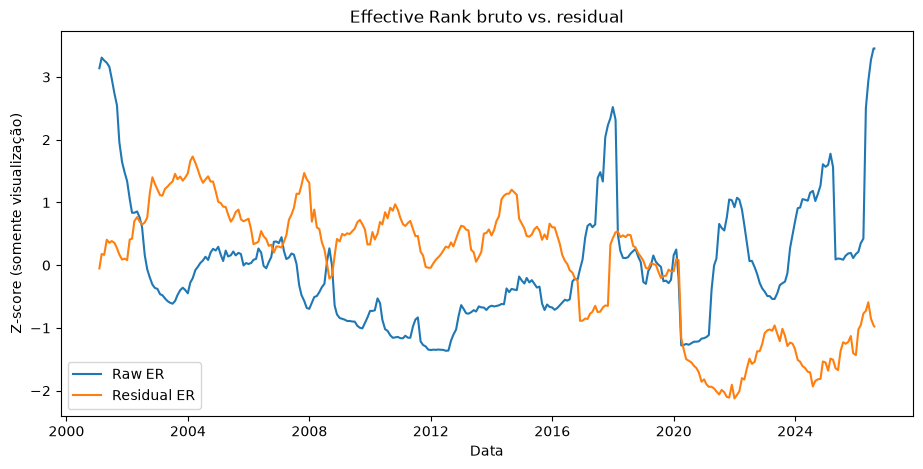

In [10]:
viz = (comparison - comparison.mean()) / comparison.std()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(viz.index, viz["raw_er"], label="Raw ER")
ax.plot(viz.index, viz["resid_er"], label="Residual ER")
ax.set_title("Effective Rank bruto vs. residual")
ax.set_xlabel("Data")
ax.set_ylabel("Z-score (somente visualização)")
ax.legend()
plt.show()

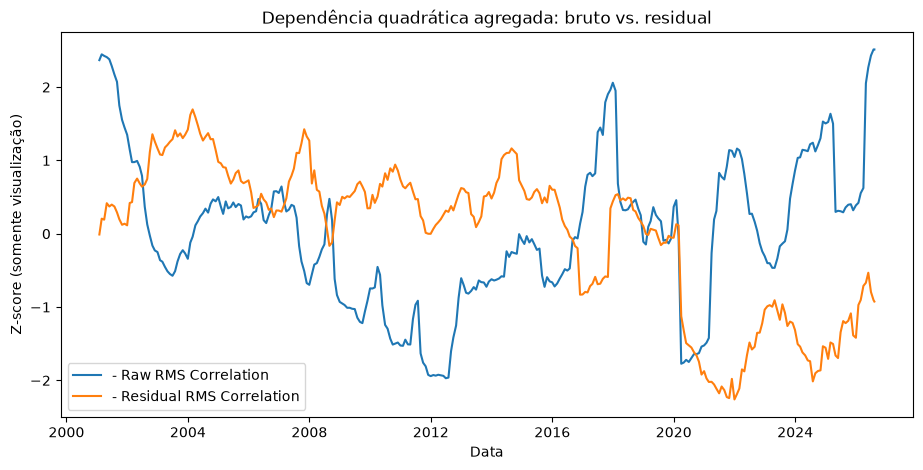

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(viz.index, -viz["raw_rms_corr"], label="- Raw RMS Correlation")
ax.plot(viz.index, -viz["resid_rms_corr"], label="- Residual RMS Correlation")
ax.set_title("Dependência quadrática agregada: bruto vs. residual")
ax.set_xlabel("Data")
ax.set_ylabel("Z-score (somente visualização)")
ax.legend()
plt.show()

## 8. Diagnóstico resumido

In [12]:
summary = pd.Series({
    "raw_ER_mean": raw_m["effective_rank"].mean(),
    "resid_ER_mean": resid_m["effective_rank"].mean(),

    "raw_mean_corr_mean": raw_m["mean_corr"].mean(),
    "resid_mean_corr_mean": resid_m["mean_corr"].mean(),

    "raw_rms_corr_mean": raw_m["rms_corr"].mean(),
    "resid_rms_corr_mean": resid_m["rms_corr"].mean(),

    "spearman_raw_ER_vs_meanCorr":
        raw_m["effective_rank"].corr(raw_m["mean_corr"], method="spearman"),

    "spearman_resid_ER_vs_meanCorr":
        resid_m["effective_rank"].corr(resid_m["mean_corr"], method="spearman"),

    "spearman_raw_ER_vs_RMS":
        raw_m["effective_rank"].corr(raw_m["rms_corr"], method="spearman"),

    "spearman_resid_ER_vs_RMS":
        resid_m["effective_rank"].corr(resid_m["rms_corr"], method="spearman"),

    "corr_rawER_vs_residER":
        comparison["raw_er"].corr(comparison["resid_er"]),

    "n_months": len(comparison),
})

display(summary)

raw_ER_mean                        2.283199
resid_ER_mean                      6.237347
raw_mean_corr_mean                 0.605150
resid_mean_corr_mean              -0.022310
raw_rms_corr_mean                  0.630141
resid_rms_corr_mean                0.237752
spearman_raw_ER_vs_meanCorr       -0.994578
spearman_resid_ER_vs_meanCorr     -0.062797
spearman_raw_ER_vs_RMS            -1.000000
spearman_resid_ER_vs_RMS          -1.000000
corr_rawER_vs_residER             -0.259435
n_months                         308.000000
dtype: float64

# PONTO DE DECISÃO — não avance automaticamente

Depois de executar a v0.3, precisamos escolher conscientemente entre:

## Caminho A — Opportunity Set simples
Se a estrutura residual for economicamente diferente, mas o participation-ratio ER continuar redundante com medidas simples, abandonamos o branding “Effective Rank” e usamos a medida mais simples defensável.

## Caminho B — ampliar a representação espectral
Podemos formular uma hipótese nova com uma medida que use mais da distribuição dos autovalores, por exemplo:

\[
p_i = \frac{\lambda_i}{\sum_j \lambda_j},
\qquad
ER_{entropy} =
\exp\left(-\sum_i p_i\ln p_i\right)
\]

Isso **não é equivalente** ao participation ratio, mas seria uma nova decisão metodológica e não poderá ser escolhida a posteriori apenas por performance.

## Caminho C — abandonar Market Dimensionality
Se residualização não produzir distinção economicamente útil e tudo continuar essencialmente uma medida de correlação, encerramos a tese antes de construir o alpha.

## O que não faremos nesta versão
Não adicionaremos Residual Momentum, thresholds ou carteira antes dessa decisão.

## Registro de decisões — v0.3

| Item | Estado |
|---|---|
| Tese central | Market Dimensionality / Opportunity Set |
| Participation-ratio ER bruto | válido, porém fortemente redundante |
| Identidade ER ↔ mean squared correlation | auditada explicitamente |
| Fator comum | SPY |
| Residualização | rolling OLS point-in-time, 252 dias |
| Estrutura residual | **A TESTAR AO EXECUTAR** |
| Alpha | **NÃO IMPLEMENTADO** |
| OOS de alpha | **NÃO DEFINIDO AINDA** |
| Próxima decisão | Caminho A, B ou C |

# 9. v0.4 — Primeiro teste econômico: Opportunity Set → Residual Momentum

A partir daqui fazemos o primeiro teste que pode **salvar ou matar a tese**.

## Hipótese econômica pré-especificada

Depois de remover o fator de mercado, uma dependência residual menor significa que os setores estão se movendo de forma mais independente.

Definimos:

\[
D_t = RMSCorr^\epsilon_t
\]

e um *opportunity score* apenas para facilitar a leitura:

\[
O_t = -D_t.
\]

Assim:

- \(O_t\) alto = menor dependência residual;
- \(O_t\) baixo = maior dependência residual.

A hipótese primária é:

\[
O_t \uparrow
\Rightarrow
\text{maior eficácia futura do alpha cross-sectional}.
\]

Isso **não está provado**. É o que testaremos.

---

## Alpha pré-especificado: Residual Momentum 12–1

Para cada setor, em cada data de decisão \(t\):

1. estimamos \(\alpha_{i,t}\) e \(\beta_{i,t}\) contra SPY usando os últimos 252 pregões;
2. calculamos os resíduos históricos nessa janela;
3. excluímos os 21 pregões mais recentes;
4. somamos os resíduos restantes:

\[
RMOM_{i,t}
=
\sum_{\tau=t-251}^{t-21}
\epsilon_{i,\tau}.
\]

O lookback **12–1 foi congelado antes de observar qualquer resultado condicionado**.

### Controle
Também calculamos momentum bruto 12–1:

\[
MOM_{i,t}
=
\sum_{\tau=t-251}^{t-21}
r_{i,\tau}.
\]

O momentum bruto não é nossa tese; ele serve como benchmark.

## 10. Como medir “qualidade futura do alpha” sem escolher uma carteira arbitrária

Com apenas 9 ETFs, escolher “top 10%” ou “top 20%” seria artificial.

Por isso a métrica **primária** será o **cross-sectional Rank IC**:

\[
IC_t =
Spearman(
Signal_{i,t},
FutureReturn_{i,t+1}
).
\]

Interpretação:

- \(IC>0\): ativos com maior sinal tenderam a ter maior retorno relativo depois;
- \(IC=0\): ranking sem informação;
- \(IC<0\): ranking apontou na direção errada.

Isso testa **informação preditiva cross-sectional** antes de decidir pesos de carteira.

Como métrica econômica secundária, usamos:

\[
Spread_t =
\text{média dos 3 maiores sinais}
-
\text{média dos 3 menores sinais}.
\]

Com 9 ativos, isso equivale a tercis de 3 ativos e evita escolher um threshold após ver os resultados.

In [13]:
# Especificação do alpha — congelada na v0.4

MOMENTUM_LOOKBACK = 252
MOMENTUM_SKIP = 21
TOP_K = 3

assert MOMENTUM_LOOKBACK == WINDOW, (
    "Nesta versão, a janela do momentum e a janela estrutural são ambas 252 dias."
)

## 11. Funções auxiliares para o alpha

O \(\beta_t\) usado para avaliar o mês seguinte fica **congelado na data da decisão**.

O retorno futuro beta-hedged de cada setor é:

\[
R^{hedged}_{i,t\to t+1}
=
\sum_{\tau=t+1}^{t_{next}}
\left(
r_{i,\tau}
-
\beta_{i,t} r_{SPY,\tau}
\right).
\]

Isso evita usar beta estimado com dados futuros para avaliar a decisão tomada em \(t\).

In [14]:
def fit_market_model(
    sector_window: pd.DataFrame,
    market_window: pd.Series,
) -> tuple[pd.Series, pd.Series, pd.DataFrame]:
    """
    Estima alpha e beta por OLS, ativo a ativo, usando somente a janela histórica.
    Retorna alpha, beta e resíduos in-sample da janela.
    """
    m = market_window.to_numpy(dtype=float)
    m_mean = m.mean()
    m_centered = m - m_mean
    var_m = np.dot(m_centered, m_centered)

    if var_m <= 0:
        raise ValueError("Variância do fator de mercado é zero.")

    alphas = {}
    betas = {}
    residuals = pd.DataFrame(
        index=sector_window.index,
        columns=sector_window.columns,
        dtype=float,
    )

    for ticker in sector_window.columns:
        y = sector_window[ticker].to_numpy(dtype=float)
        y_mean = y.mean()
        y_centered = y - y_mean

        beta = np.dot(m_centered, y_centered) / var_m
        alpha = y_mean - beta * m_mean

        fitted = alpha + beta * m
        residuals[ticker] = y - fitted

        alphas[ticker] = alpha
        betas[ticker] = beta

    return pd.Series(alphas), pd.Series(betas), residuals


def spearman_cross_section(x: pd.Series, y: pd.Series) -> float:
    aligned = pd.concat([x.rename("x"), y.rename("y")], axis=1).dropna()
    if len(aligned) < 3:
        return np.nan
    return float(aligned["x"].corr(aligned["y"], method="spearman"))


def top_bottom_spread(
    signal: pd.Series,
    future_return: pd.Series,
    top_k: int = 3,
) -> float:
    aligned = pd.concat(
        [signal.rename("signal"), future_return.rename("future")],
        axis=1
    ).dropna()

    if len(aligned) < 2 * top_k:
        return np.nan

    ranked = aligned.sort_values("signal")
    bottom = ranked.head(top_k)["future"].mean()
    top = ranked.tail(top_k)["future"].mean()

    return float(top - bottom)

## 12. Construção do painel mensal de teste

Cada linha será uma decisão mensal.

Para a data \(t\), armazenamos:

- `resid_rms_corr`: intensidade da dependência residual observada em \(t\);
- `opportunity_score = -resid_rms_corr`;
- `resid_er`: transformação equivalente em participation-ratio ER;
- `raw_rms_corr`: controle estrutural bruto;
- `IC` do Residual Momentum no mês seguinte;
- `IC` do momentum bruto;
- spreads top 3 – bottom 3 para ambos os sinais.

A data da decisão é sempre uma data realmente observada.

In [15]:
def build_monthly_alpha_panel(
    sector_rets: pd.DataFrame,
    market_rets: pd.Series,
    residual_structure_monthly: pd.DataFrame,
    raw_structure_monthly: pd.DataFrame,
    lookback: int = 252,
    skip: int = 21,
    top_k: int = 3,
) -> pd.DataFrame:
    aligned = sector_rets.join(
        market_rets.rename("market"),
        how="inner"
    ).dropna()

    sectors = aligned[sector_rets.columns]
    market = aligned["market"]

    decision_dates = residual_structure_monthly.index.intersection(
        raw_structure_monthly.index
    ).sort_values()

    # Precisamos de uma próxima data de decisão para medir o mês seguinte.
    rows = []

    for j in range(len(decision_dates) - 1):
        t = decision_dates[j]
        t_next = decision_dates[j + 1]

        if t not in aligned.index or t_next not in aligned.index:
            continue

        pos = aligned.index.get_loc(t)

        # Precisamos de lookback observações até e incluindo t.
        if not isinstance(pos, (int, np.integer)) or pos + 1 < lookback:
            continue

        hist = aligned.iloc[pos - lookback + 1 : pos + 1]
        sector_hist = hist[sector_rets.columns]
        market_hist = hist["market"]

        _, betas_t, residuals_hist = fit_market_model(
            sector_hist,
            market_hist,
        )

        # 12-1: exclui os últimos 21 pregões.
        residual_signal_window = residuals_hist.iloc[:-skip]
        raw_signal_window = sector_hist.iloc[:-skip]

        if residual_signal_window.empty or raw_signal_window.empty:
            continue

        resid_mom = residual_signal_window.sum(axis=0)
        raw_mom = raw_signal_window.sum(axis=0)

        # Retorno futuro: estritamente após t até a próxima data mensal.
        future_mask = (aligned.index > t) & (aligned.index <= t_next)
        future = aligned.loc[future_mask]

        if future.empty:
            continue

        future_sector = future[sector_rets.columns]
        future_market = future["market"]

        # Beta de t fica congelado durante todo o mês seguinte.
        future_hedged_daily = future_sector.sub(
            future_market.to_numpy()[:, None] * betas_t.to_numpy()[None, :],
            axis=0,
        )

        future_hedged = future_hedged_daily.sum(axis=0)
        future_raw = future_sector.sum(axis=0)

        row = {
            "date": t,
            "next_date": t_next,

            "resid_rms_corr":
                float(residual_structure_monthly.loc[t, "rms_corr"]),
            "opportunity_score":
                -float(residual_structure_monthly.loc[t, "rms_corr"]),
            "resid_er":
                float(residual_structure_monthly.loc[t, "effective_rank"]),

            "raw_rms_corr":
                float(raw_structure_monthly.loc[t, "rms_corr"]),
            "raw_er":
                float(raw_structure_monthly.loc[t, "effective_rank"]),

            "ic_resid_mom":
                spearman_cross_section(resid_mom, future_hedged),
            "ic_raw_mom":
                spearman_cross_section(raw_mom, future_hedged),

            "spread_resid_mom":
                top_bottom_spread(resid_mom, future_hedged, top_k),
            "spread_raw_mom":
                top_bottom_spread(raw_mom, future_hedged, top_k),

            # Controles descritivos
            "future_market_log_return":
                float(future_market.sum()),
            "future_cross_sectional_dispersion":
                float(future_raw.std()),
        }

        rows.append(row)

    panel = pd.DataFrame(rows).set_index("date").sort_index()
    return panel


alpha_panel = build_monthly_alpha_panel(
    sector_returns,
    market_returns,
    resid_m,
    raw_m,
    lookback=MOMENTUM_LOOKBACK,
    skip=MOMENTUM_SKIP,
    top_k=TOP_K,
)

print("Número total de decisões mensais construídas:", len(alpha_panel))
display(alpha_panel.head())
display(alpha_panel.tail())

Número total de decisões mensais construídas: 307


,next_date,resid_rms_corr,opportunity_score,resid_er,raw_rms_corr,raw_er,ic_resid_mom,ic_raw_mom,spread_resid_mom,spread_raw_mom,future_market_log_return,future_cross_sectional_dispersion
date,,,,,,,,,,,,
2001-01-31,2001-02-28,0.238426,-0.238426,6.186513,0.347788,4.573984,0.266667,0.166667,0.051486,0.051486,-0.100248,0.094413
2001-02-28,2001-03-30,0.224414,-0.224414,6.415309,0.338358,4.697554,0.266667,0.116667,-0.001494,0.012129,-0.057669,0.037816
2001-03-30,2001-04-30,0.225307,-0.225307,6.400664,0.340892,4.664037,0.633333,0.150000,0.062681,-0.001069,0.081986,0.042259
2001-04-30,2001-05-31,0.210728,-0.210728,6.640844,0.342914,4.637454,0.250000,-0.033333,0.004524,0.005123,-0.005621,0.028318
2001-05-31,2001-06-29,0.213621,-0.213621,6.593070,0.346460,4.591194,-0.166667,-0.400000,-0.016884,-0.027747,-0.024118,0.035208


,next_date,resid_rms_corr,opportunity_score,resid_er,raw_rms_corr,raw_er,ic_resid_mom,ic_raw_mom,spread_resid_mom,spread_raw_mom,future_market_log_return,future_cross_sectional_dispersion
date,,,,,,,,,,,,
2026-03-31,2026-04-30,0.283959,-0.283959,5.470926,0.555807,2.592636,0.350000,0.316667,0.003904,0.022005,0.099893,0.061119
2026-04-30,2026-05-29,0.281150,-0.281150,5.513484,0.385471,4.112024,-0.250000,-0.216667,-0.042813,0.022292,0.051288,0.070397
2026-05-29,2026-06-30,0.272275,-0.272275,5.649467,0.359575,4.424013,-0.316667,-0.250000,-0.036737,-0.025564,-0.010346,0.040520
2026-06-30,2026-07-31,0.289335,-0.289335,5.390133,0.340357,4.671094,0.283333,-0.350000,0.024401,-0.023966,0.000348,0.056724
2026-07-31,2026-08-10,0.296498,-0.296498,5.283897,0.330416,4.804108,0.000000,0.483333,0.004003,0.009928,0.034213,0.027244


# 13. Holdout temporal — ainda fechado

Para reduzir nossa liberdade de escolha, a v0.4 usa uma regra mecânica:

- **70% iniciais das decisões mensais:** Development / Research
- **30% finais:** Holdout OOS

O corte é baseado **somente na ordem temporal**, não em performance.

> A v0.4 **não mostrará resultados do holdout**.
> Ele será aberto apenas em uma versão posterior, depois de decidirmos se a especificação de development está congelada.

Isso significa que podemos abandonar a tese usando apenas development, mas não podemos “consertá-la” depois de abrir o OOS.

In [16]:
split_idx = int(np.floor(len(alpha_panel) * 0.70))

dev = alpha_panel.iloc[:split_idx].copy()
oos_locked = alpha_panel.iloc[split_idx:].copy()

print("Development:")
print(dev.index.min(), "→", dev.index.max(), "| n =", len(dev))

print()
print("OOS LOCKED:")
print(oos_locked.index.min(), "→", oos_locked.index.max(), "| n =", len(oos_locked))

# IMPORTANTE:
# Não exibimos nenhuma métrica de retorno/IC do OOS nesta versão.

Development:
2001-01-31 00:00:00 → 2018-10-31 00:00:00 | n = 214

OOS LOCKED:
2018-11-30 00:00:00 → 2026-07-31 00:00:00 | n = 93


## 14. Primeiro sanity check econômico — Development apenas

Antes de condicionar por Opportunity Set, verificamos se o alpha-base possui **alguma informação cross-sectional no development**.

Isso não exige Sharpe alto.

Queremos apenas saber se o instrumento experimental não é completamente vazio.

Medimos:

\[
E[IC]
\]

e o spread médio top–bottom.

Se o Residual Momentum tiver IC praticamente zero e extremamente instável, ainda podemos testar condicionamento, mas a interpretação de “confiabilidade do alpha” fica mais fraca.

In [17]:
dev_baseline_summary = pd.Series({
    "n_months": len(dev),

    "mean_IC_resid_mom": dev["ic_resid_mom"].mean(),
    "median_IC_resid_mom": dev["ic_resid_mom"].median(),
    "IC_hit_rate_resid_mom": (dev["ic_resid_mom"] > 0).mean(),

    "mean_IC_raw_mom": dev["ic_raw_mom"].mean(),
    "median_IC_raw_mom": dev["ic_raw_mom"].median(),
    "IC_hit_rate_raw_mom": (dev["ic_raw_mom"] > 0).mean(),

    "mean_spread_resid_mom": dev["spread_resid_mom"].mean(),
    "median_spread_resid_mom": dev["spread_resid_mom"].median(),

    "mean_spread_raw_mom": dev["spread_raw_mom"].mean(),
    "median_spread_raw_mom": dev["spread_raw_mom"].median(),
})

display(dev_baseline_summary)

n_months                   214.000000
mean_IC_resid_mom            0.049611
median_IC_resid_mom          0.091667
IC_hit_rate_resid_mom        0.556075
mean_IC_raw_mom              0.000312
median_IC_raw_mom            0.033333
IC_hit_rate_raw_mom          0.514019
mean_spread_resid_mom        0.003741
median_spread_resid_mom      0.004084
mean_spread_raw_mom          0.000392
median_spread_raw_mom        0.001580
dtype: float64

# 15. Teste principal — Opportunity Score vs. qualidade futura do Residual Momentum

A especificação principal usa:

\[
O_t = -RMSCorr^\epsilon_t
\]

onde valores maiores significam menor dependência residual.

Testaremos em development:

1. relação contínua entre \(O_t\) e \(IC_{t+1}\);
2. relação entre \(O_t\) e spread futuro;
3. comportamento por quintis de \(O_t\).

A hipótese direcional pré-especificada é:

\[
O_t \uparrow
\Rightarrow
IC_{ResidualMomentum,t+1} \uparrow.
\]

In [18]:
continuous_dev = pd.Series({
    "pearson_opportunity_vs_IC_resid":
        dev["opportunity_score"].corr(dev["ic_resid_mom"], method="pearson"),

    "spearman_opportunity_vs_IC_resid":
        dev["opportunity_score"].corr(dev["ic_resid_mom"], method="spearman"),

    "pearson_opportunity_vs_spread_resid":
        dev["opportunity_score"].corr(dev["spread_resid_mom"], method="pearson"),

    "spearman_opportunity_vs_spread_resid":
        dev["opportunity_score"].corr(dev["spread_resid_mom"], method="spearman"),
})

display(continuous_dev)

pearson_opportunity_vs_IC_resid        -0.030046
spearman_opportunity_vs_IC_resid       -0.043820
pearson_opportunity_vs_spread_resid    -0.081510
spearman_opportunity_vs_spread_resid   -0.086937
dtype: float64

In [19]:
dev_q = dev.copy()

dev_q["opportunity_quintile"] = pd.qcut(
    dev_q["opportunity_score"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)

by_q = (
    dev_q.groupby("opportunity_quintile", observed=True)
         .agg(
             n=("ic_resid_mom", "size"),

             opportunity_mean=("opportunity_score", "mean"),
             residual_dependence_mean=("resid_rms_corr", "mean"),

             IC_resid_mean=("ic_resid_mom", "mean"),
             IC_resid_median=("ic_resid_mom", "median"),
             IC_resid_hit_rate=("ic_resid_mom", lambda s: (s > 0).mean()),

             spread_resid_mean=("spread_resid_mom", "mean"),
             spread_resid_median=("spread_resid_mom", "median"),

             IC_raw_mean=("ic_raw_mom", "mean"),
             spread_raw_mean=("spread_raw_mom", "mean"),
         )
)

display(by_q)

,n,opportunity_mean,residual_dependence_mean,IC_resid_mean,IC_resid_median,IC_resid_hit_rate,spread_resid_mean,spread_resid_median,IC_raw_mean,spread_raw_mean
opportunity_quintile,,,,,,,,,,
Q1,43,-0.246736,0.246736,0.160078,0.183333,0.604651,0.008759,0.006459,0.040698,0.000759
Q2,43,-0.214297,0.214297,-0.000388,0.000000,0.488372,0.008221,0.002294,-0.121318,-0.006402
Q3,42,-0.203200,0.203200,0.039286,0.066667,0.547619,0.001541,0.004675,0.054762,0.000960
Q4,43,-0.189936,0.189936,-0.077519,-0.016667,0.488372,-0.002470,0.002002,-0.005814,0.003416
Q5,43,-0.156850,0.156850,0.126357,0.116667,0.651163,0.002606,0.007386,0.034496,0.003241


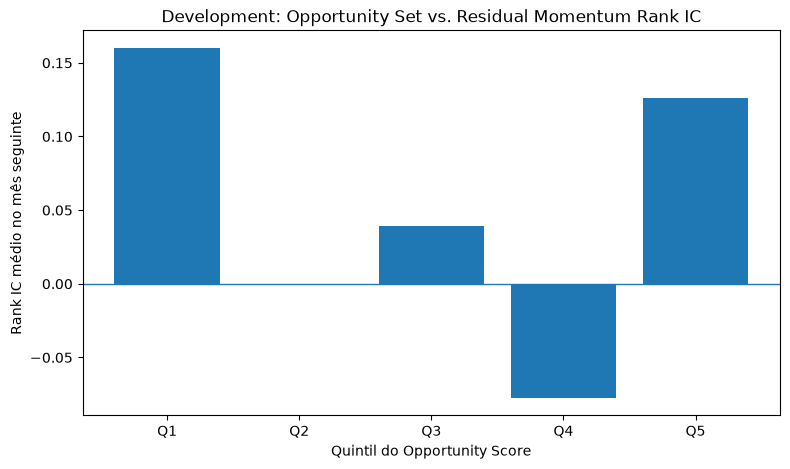

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    by_q.index.astype(str),
    by_q["IC_resid_mean"],
)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Quintil do Opportunity Score")
ax.set_ylabel("Rank IC médio no mês seguinte")
ax.set_title("Development: Opportunity Set vs. Residual Momentum Rank IC")
plt.show()

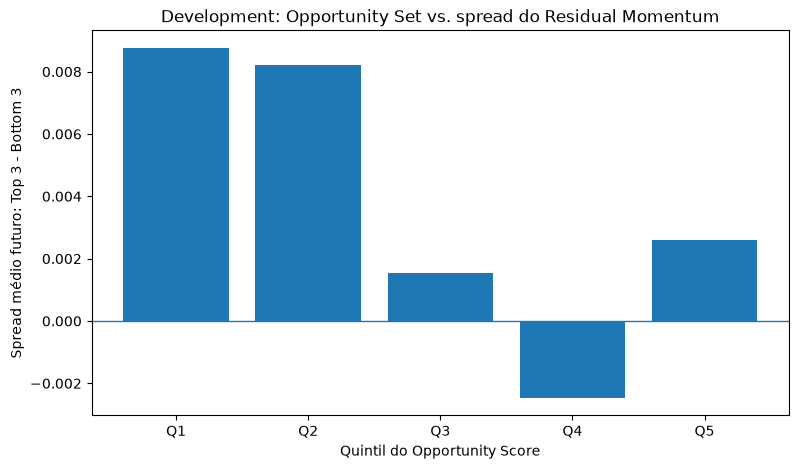

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    by_q.index.astype(str),
    by_q["spread_resid_mean"],
)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Quintil do Opportunity Score")
ax.set_ylabel("Spread médio futuro: Top 3 - Bottom 3")
ax.set_title("Development: Opportunity Set vs. spread do Residual Momentum")
plt.show()

# 16. Controles — estamos vendo Opportunity Set ou outra coisa trivial?

Ainda no **development**, comparamos a relação usando:

### A. Dependência residual — variável principal
\[
-RMSCorr^\epsilon_t
\]

### B. Dependência bruta
\[
-RMSCorr^{raw}_t
\]

### C. Effective Rank residual
Como ER residual é transformação monotônica de RMS residual, esperamos resultados de ranking praticamente equivalentes.

Isso é proposital: se ER parecer “melhor” apenas por escala, não conta como evidência incremental.

In [22]:
control_comparison = pd.DataFrame({
    "metric": [
        "Residual Opportunity (-Residual RMS Corr)",
        "Raw Opportunity (-Raw RMS Corr)",
        "Residual Effective Rank",
        "Raw Effective Rank",
    ],
    "spearman_vs_IC_resid_mom": [
        dev["opportunity_score"].corr(dev["ic_resid_mom"], method="spearman"),
        (-dev["raw_rms_corr"]).corr(dev["ic_resid_mom"], method="spearman"),
        dev["resid_er"].corr(dev["ic_resid_mom"], method="spearman"),
        dev["raw_er"].corr(dev["ic_resid_mom"], method="spearman"),
    ],
    "spearman_vs_spread_resid_mom": [
        dev["opportunity_score"].corr(dev["spread_resid_mom"], method="spearman"),
        (-dev["raw_rms_corr"]).corr(dev["spread_resid_mom"], method="spearman"),
        dev["resid_er"].corr(dev["spread_resid_mom"], method="spearman"),
        dev["raw_er"].corr(dev["spread_resid_mom"], method="spearman"),
    ],
})

display(control_comparison)

,metric,spearman_vs_IC_resid_mom,spearman_vs_spread_resid_mom
0,Residual Opportunity (-Residual RMS Corr),-0.043820,-0.086937
1,Raw Opportunity (-Raw RMS Corr),0.054149,0.012831
2,Residual Effective Rank,-0.043820,-0.086937
3,Raw Effective Rank,0.054149,0.012831


# 17. Critério de decisão da v0.4

A v0.4 **não procura “significância perfeita”** e não abre o OOS.

## GO provisório
Avançamos para congelar a especificação e abrir OOS somente se o development mostrar conjuntamente:

1. relação economicamente coerente entre Opportunity Score e qualidade do Residual Momentum;
2. efeito não dependente apenas de uma observação extrema;
3. quintis com alguma estrutura/ordenação interpretável;
4. resultado do residual Opportunity Set pelo menos conceitualmente mais interessante que a dependência bruta.

## CONDITIONAL GO
Se a relação existir, mas for fraca ou não monotônica, analisamos estabilidade temporal **sem alterar 12–1 ou escolher novos parâmetros**.

## NO-GO
Encerramos a tese se:

- IC/spread forem essencialmente aleatórios em todos os estados;
- relação mudar de sinal sem padrão;
- somente a métrica bruta explicar o resultado;
- o efeito depender de poucos episódios extremos.

---

## Importante

Não abra ou resuma `oos_locked` antes da decisão.

A próxima versão só deve existir depois de avaliarmos juntos os outputs de development.

## Registro — v0.4

| Item | Decisão congelada |
|---|---|
| Tese | Residual Dependence / Opportunity Set |
| Medida principal | `- Residual RMS Correlation` |
| ER | transformação interpretável, não fonte independente |
| Alpha principal | Residual Momentum |
| Lookback | 12–1 |
| Controle de alpha | Momentum bruto 12–1 |
| Métrica primária | Cross-sectional Rank IC |
| Métrica econômica secundária | Top 3 – Bottom 3 spread |
| Frequência | mensal |
| Beta hedge futuro | beta estimado em \(t\) e congelado |
| Development | 70% inicial da amostra |
| OOS | 30% final, **LOCKED** |
| Threshold de trading | nenhum |
| Carteira final | ainda não construída |

# 18. v0.5 — Adaptive Factor Neutralization

## Correção metodológica importante

Na v0.4 nós já observamos **estatísticas agregadas de todo o período 2001–2018**.

Portanto, seria incorreto dividir agora esse mesmo intervalo em “design” e “internal validation” e chamar a parte final de validação limpa.

Ela **já foi parcialmente contaminada pelo processo de pesquisa**.

Assim, a estrutura temporal correta passa a ser:

\[
\boxed{
2001\text{–}2018 = Research / Exploratory Sample
}
\]

\[
\boxed{
2018\text{–}2026 = Final OOS realmente intocado
}
\]

Podemos dividir 2001–2018 em subperíodos para testar **consistência interna**, mas isso não será tratado como confirmação independente.

> A confirmação real da nova hipótese só poderá vir do OOS final, que continua fechado nesta versão.

## 19. Nova hipótese congelada antes de abrir o OOS

O resultado exploratório mais promissor da v0.4 foi:

\[
ResidualMomentum_{12-1}
\]

ter apresentado maior capacidade cross-sectional que o momentum bruto no research sample.

Isso motivou uma nova pergunta:

> **Quando neutralizar o fator de mercado melhora um sinal de momentum?**

Para cada setor:

\[
r_{i,t}
=
\alpha_{i,t}
+
\beta_{i,t}r_{SPY,t}
+
\epsilon_{i,t}.
\]

Definimos a **Market Commonality** em \(t\) como:

\[
Commonality_t
=
\frac{1}{N}
\sum_{i=1}^{N}R^2_{i,t},
\]

onde cada \(R^2_{i,t}\) vem do market model estimado com os 252 pregões disponíveis até \(t\).

A variável-alvo principal é:

\[
\Delta IC_{t+1}
=
IC^{ResidualMom}_{t+1}
-
IC^{RawMom}_{t+1}.
\]

### Hipótese direcional pré-especificada

\[
\boxed{
Commonality_t \uparrow
\Rightarrow
\Delta IC_{t+1} \uparrow
}
\]

Interpretação:

> Quanto mais o fator de mercado domina os movimentos dos setores, maior deveria ser o valor incremental de retirar esse fator antes de construir o ranking de momentum.

### Métrica econômica secundária

\[
\Delta Spread_{t+1}
=
Spread^{ResidualMom}_{t+1}
-
Spread^{RawMom}_{t+1}.
\]

Nenhum threshold de trading será criado nesta versão.

## 20. Por que \(R^2\) é preferido aqui

Nesta hipótese, não estamos tentando representar a “geometria” do mercado.

Queremos responder diretamente:

> **Quanto do movimento dos setores está sendo explicado pelo fator de mercado?**

O \(R^2\) do market model é uma medida simples e auditável para isso.

Isso também evita recuperar o Effective Rank apenas para preservar uma narrativa anterior.

In [23]:
def market_model_r2(
    sector_window: pd.DataFrame,
    market_window: pd.Series,
) -> pd.Series:
    """
    R² do market model por ativo, estimado somente com a janela histórica recebida.
    """
    _, _, residuals = fit_market_model(sector_window, market_window)

    r2 = {}

    for ticker in sector_window.columns:
        y = sector_window[ticker]
        resid = residuals[ticker]

        sse = float(np.square(resid).sum())
        sst = float(np.square(y - y.mean()).sum())

        r2[ticker] = np.nan if sst <= 0 else 1.0 - sse / sst

    return pd.Series(r2, dtype=float)


def build_market_commonality_series(
    sector_rets: pd.DataFrame,
    market_rets: pd.Series,
    decision_dates: pd.DatetimeIndex,
    lookback: int = 252,
) -> pd.DataFrame:
    aligned = sector_rets.join(
        market_rets.rename("market"),
        how="inner"
    ).dropna()

    rows = []

    for t in decision_dates:
        if t not in aligned.index:
            continue

        pos = aligned.index.get_loc(t)

        if not isinstance(pos, (int, np.integer)) or pos + 1 < lookback:
            continue

        hist = aligned.iloc[pos - lookback + 1 : pos + 1]
        sector_hist = hist[sector_rets.columns]
        market_hist = hist["market"]

        r2_by_asset = market_model_r2(sector_hist, market_hist)

        rows.append({
            "date": t,
            "market_commonality_mean_r2": float(r2_by_asset.mean()),
            "market_commonality_median_r2": float(r2_by_asset.median()),
            "market_commonality_min_r2": float(r2_by_asset.min()),
            "market_commonality_max_r2": float(r2_by_asset.max()),
            "market_commonality_std_r2": float(r2_by_asset.std()),
        })

    return pd.DataFrame(rows).set_index("date").sort_index()


commonality = build_market_commonality_series(
    sector_returns,
    market_returns,
    alpha_panel.index,
    lookback=MOMENTUM_LOOKBACK,
)

display(commonality.head())
display(commonality.tail())

,market_commonality_mean_r2,market_commonality_median_r2,market_commonality_min_r2,market_commonality_max_r2,market_commonality_std_r2
date,,,,,
2001-01-31,0.282842,0.327290,0.008282,0.634108,0.243764
2001-02-28,0.282075,0.318946,0.002355,0.662705,0.252322
2001-03-30,0.285640,0.302936,0.008115,0.671994,0.257557
2001-04-30,0.289651,0.297183,0.005391,0.700489,0.263541
2001-05-31,0.290110,0.312786,0.006845,0.689200,0.260498


,market_commonality_mean_r2,market_commonality_median_r2,market_commonality_min_r2,market_commonality_max_r2,market_commonality_std_r2
date,,,,,
2026-03-31,0.520957,0.582933,0.114132,0.880588,0.283971
2026-04-30,0.352000,0.342011,0.002937,0.797377,0.304801
2026-05-29,0.327222,0.328807,0.005981,0.771113,0.289488
2026-06-30,0.299930,0.306010,0.000560,0.763895,0.291255
2026-07-31,0.284712,0.284620,0.004578,0.737705,0.283695


## 21. Painel da nova hipótese

O painel abaixo usa **apenas variáveis já congeladas**:

- Residual Momentum 12–1;
- Raw Momentum 12–1;
- Rank IC;
- spread Top 3 – Bottom 3;
- Market Commonality via mean \(R^2\).

Não alteramos o alpha depois de observar o resultado da v0.4.

In [24]:
adaptive_panel = alpha_panel.join(commonality, how="inner").copy()

adaptive_panel["delta_ic"] = (
    adaptive_panel["ic_resid_mom"]
    - adaptive_panel["ic_raw_mom"]
)

adaptive_panel["delta_spread"] = (
    adaptive_panel["spread_resid_mom"]
    - adaptive_panel["spread_raw_mom"]
)

# Mantém a mesma separação temporal já criada na v0.4.
research = adaptive_panel.loc[dev.index].copy()
final_oos_locked = adaptive_panel.loc[oos_locked.index].copy()

print("RESEARCH SAMPLE:")
print(research.index.min(), "→", research.index.max(), "| n =", len(research))

print()
print("FINAL OOS LOCKED:")
print(final_oos_locked.index.min(), "→", final_oos_locked.index.max(), "| n =", len(final_oos_locked))

# Nenhuma métrica do OOS é exibida nesta versão.

RESEARCH SAMPLE:
2001-01-31 00:00:00 → 2018-10-31 00:00:00 | n = 214

FINAL OOS LOCKED:
2018-11-30 00:00:00 → 2026-07-31 00:00:00 | n = 93


# 22. Diagnóstico exploratório no Research Sample

Tudo abaixo é **exploratório**, porque a hipótese nasceu após observar resultados desse mesmo intervalo.

O objetivo é decidir se a relação é coerente o suficiente para justificar **uma única abertura posterior do OOS**.

Não usaremos esta etapa para escolher parâmetros.

In [25]:
research_summary = pd.Series({
    "n_months": len(research),

    "commonality_mean":
        research["market_commonality_mean_r2"].mean(),

    "commonality_std":
        research["market_commonality_mean_r2"].std(),

    "delta_IC_mean":
        research["delta_ic"].mean(),

    "delta_IC_median":
        research["delta_ic"].median(),

    "delta_IC_positive_rate":
        (research["delta_ic"] > 0).mean(),

    "delta_spread_mean":
        research["delta_spread"].mean(),

    "delta_spread_median":
        research["delta_spread"].median(),
})

display(research_summary)

n_months                  214.000000
commonality_mean            0.649952
commonality_std             0.126499
delta_IC_mean               0.049299
delta_IC_median             0.091667
delta_IC_positive_rate      0.542056
delta_spread_mean           0.003349
delta_spread_median         0.001926
dtype: float64

## 23. Teste contínuo exploratório

Hipótese:

\[
Commonality_t \uparrow
\Rightarrow
\Delta IC_{t+1} \uparrow.
\]

O Spearman é a métrica primária porque não exige relação linear.

In [26]:
adaptive_continuous = pd.Series({
    "pearson_commonality_vs_delta_IC":
        research["market_commonality_mean_r2"].corr(
            research["delta_ic"],
            method="pearson",
        ),

    "spearman_commonality_vs_delta_IC":
        research["market_commonality_mean_r2"].corr(
            research["delta_ic"],
            method="spearman",
        ),

    "pearson_commonality_vs_delta_spread":
        research["market_commonality_mean_r2"].corr(
            research["delta_spread"],
            method="pearson",
        ),

    "spearman_commonality_vs_delta_spread":
        research["market_commonality_mean_r2"].corr(
            research["delta_spread"],
            method="spearman",
        ),
})

display(adaptive_continuous)

pearson_commonality_vs_delta_IC        -0.051270
spearman_commonality_vs_delta_IC       -0.059331
pearson_commonality_vs_delta_spread    -0.035728
spearman_commonality_vs_delta_spread   -0.047723
dtype: float64

## 24. Quintis de Market Commonality — exploratório

Se a hipótese tiver alguma estrutura, esperamos que o benefício relativo da neutralização tenda a crescer à medida que a commonality aumenta.

Não exigimos monotonicidade perfeita, mas uma forma completamente errática enfraquece muito a tese.

In [27]:
research_q = research.copy()

research_q["commonality_quintile"] = pd.qcut(
    research_q["market_commonality_mean_r2"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)

commonality_by_q = (
    research_q.groupby("commonality_quintile", observed=True)
              .agg(
                  n=("delta_ic", "size"),

                  commonality_mean=(
                      "market_commonality_mean_r2",
                      "mean"
                  ),

                  delta_IC_mean=("delta_ic", "mean"),
                  delta_IC_median=("delta_ic", "median"),
                  delta_IC_positive_rate=(
                      "delta_ic",
                      lambda s: (s > 0).mean()
                  ),

                  delta_spread_mean=("delta_spread", "mean"),
                  delta_spread_median=("delta_spread", "median"),

                  IC_resid_mean=("ic_resid_mom", "mean"),
                  IC_raw_mean=("ic_raw_mom", "mean"),
              )
)

display(commonality_by_q)

,n,commonality_mean,delta_IC_mean,delta_IC_median,delta_IC_positive_rate,delta_spread_mean,delta_spread_median,IC_resid_mean,IC_raw_mean
commonality_quintile,,,,,,,,,
Q1,43,0.466152,0.023256,0.100000,0.558140,0.002688,-0.000863,0.078295,0.055039
Q2,43,0.591891,0.111240,0.100000,0.604651,0.004628,0.002005,-0.029070,-0.140310
Q3,42,0.663930,0.101984,0.116667,0.547619,0.006753,0.003315,0.145635,0.043651
Q4,43,0.721937,0.072481,0.150000,0.534884,0.004768,0.005302,0.102713,0.030233
Q5,43,0.806173,-0.061240,-0.066667,0.465116,-0.002012,-0.006191,-0.047287,0.013953


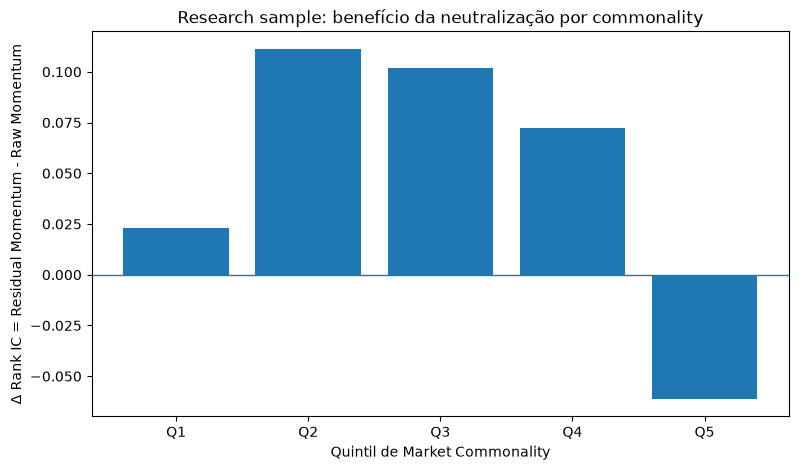

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    commonality_by_q.index.astype(str),
    commonality_by_q["delta_IC_mean"],
)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Quintil de Market Commonality")
ax.set_ylabel("Δ Rank IC = Residual Momentum - Raw Momentum")
ax.set_title("Research sample: benefício da neutralização por commonality")
plt.show()

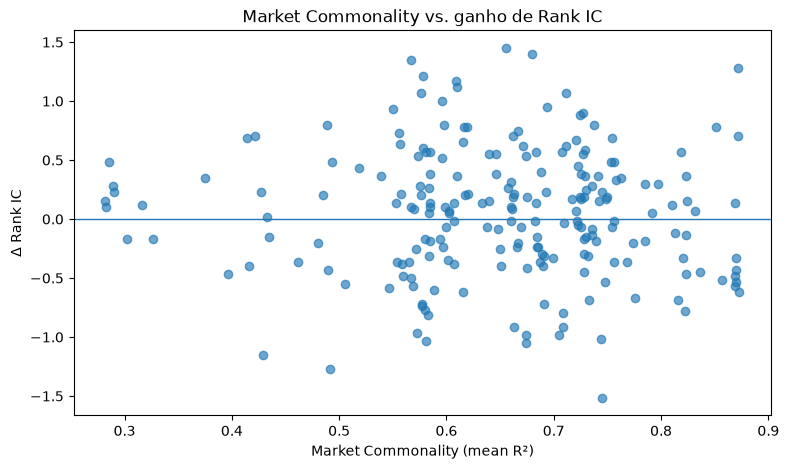

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    research["market_commonality_mean_r2"],
    research["delta_ic"],
    alpha=0.65,
)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("Market Commonality (mean R²)")
ax.set_ylabel("Δ Rank IC")
ax.set_title("Market Commonality vs. ganho de Rank IC")
plt.show()

# 25. Consistência temporal dentro do Research Sample

Como todo o intervalo 2001–2018 já foi parcialmente observado durante o research, isto **não é validação independente**.

Dividimos mecanicamente o research sample em três blocos cronológicos apenas para verificar se a relação está concentrada em uma única época.

In [ ]:
research_blocks = np.array_split(research, 3)

block_rows = []

for idx, block in enumerate(research_blocks, start=1):
    research_blocks = np.array_split(np.arange(len(research)), 3)

    block_rows = []

    for idx, block_idx in enumerate(research_blocks, start=1):
        block = research.iloc[block_idx]

        block_rows.append({
            "block": f"B{idx}",
            "start": block.index.min(),
            "end": block.index.max(),
            "n": len(block),
            "mean_commonality": block["market_commonality_mean_r2"].mean(),
            "mean_delta_IC": block["delta_ic"].mean(),
            "median_delta_IC": block["delta_ic"].median(),
            "spearman_commonality_vs_delta_IC": block["market_commonality_mean_r2"].corr(
                block["delta_ic"],
                method="spearman",
            ),
            "mean_delta_spread": block["delta_spread"].mean(),
        })

    temporal_consistency = pd.DataFrame(block_rows).set_index("block")
    display(temporal_consistency)

temporal_consistency = pd.DataFrame(block_rows).set_index("block")

display(temporal_consistency)

AttributeError: 'numpy.ndarray' object has no attribute 'index'

# 26. Controle: Market Commonality é só correlação bruta renomeada?

Não precisamos que Commonality seja completamente independente da correlação bruta.

Mas devemos saber o quanto elas se sobrepõem.

Isso ajuda a decidir se o modelo de fatores oferece interpretação adicional ou apenas uma nova escala para o mesmo fenômeno.

In [ ]:
commonality_controls = pd.Series({
    "pearson_commonality_vs_raw_RMS_corr":
        research["market_commonality_mean_r2"].corr(
            research["raw_rms_corr"],
            method="pearson",
        ),

    "spearman_commonality_vs_raw_RMS_corr":
        research["market_commonality_mean_r2"].corr(
            research["raw_rms_corr"],
            method="spearman",
        ),

    "pearson_commonality_vs_residual_RMS_corr":
        research["market_commonality_mean_r2"].corr(
            research["resid_rms_corr"],
            method="pearson",
        ),

    "spearman_commonality_vs_residual_RMS_corr":
        research["market_commonality_mean_r2"].corr(
            research["resid_rms_corr"],
            method="spearman",
        ),
})

display(commonality_controls)

# 27. Critério para decidir se vale gastar o Final OOS

Como o research sample é exploratório, **não existe confirmação aqui**.

A decisão é apenas:

> A hipótese está suficientemente coerente para justificar uma abertura única do OOS?

## Candidato a GO para abertura do OOS

A relação deve, no mínimo:

1. ter sinal positivo no Spearman `Commonality → ΔIC`;
2. apresentar interpretação coerente nos quintis;
3. não estar concentrada inteiramente em um único bloco temporal;
4. mostrar algum benefício econômico secundário em `ΔSpread`;
5. não exigir mudança do 12–1, do SPY, dos 252 dias ou da métrica após observar resultados.

## NO-GO sem abrir OOS

Se a relação for praticamente zero, de sinal contrário ou estruturalmente errática, abandonamos Adaptive Factor Neutralization **sem gastar o holdout final**.

## Regra crítica

Se decidirmos abrir o OOS na próxima versão:

- será aberto **uma única vez**;
- não mudaremos a especificação depois;
- resultado negativo encerrará a tese;
- não voltaremos para 6–1, outro benchmark ou outro threshold.

## Registro de governança — v0.5

| Item | Status |
|---|---|
| Nova tese | Adaptive Factor Neutralization |
| Alpha residual | Residual Momentum 12–1 |
| Controle | Raw Momentum 12–1 |
| Fator | SPY |
| Janela do market model | 252 pregões |
| Variável explicativa | Mean \(R^2\) cross-sectional |
| Target primário | \(\Delta IC\) |
| Target secundário | \(\Delta Spread\) |
| 2001–2018 | Research sample já contaminado/exploratório |
| 2018–2026 | **Final OOS intocado** |
| Threshold de trading | nenhum |
| Carteira | ainda não construída |
| Próxima decisão | abrir ou não o Final OOS |

> A v0.5 não produz nenhuma métrica do OOS.